importing all the necessary libraries 

In [2]:
import re
import nltk
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


### Read the raw analyst rating file ###

In [4]:
# Load the CSV file into a Pandas DataFrame
df =pd.read_csv(r"C:\Users\hp\Downloads\Data-20241212T111214Z-001\Data\raw_analyst_ratings.csv\raw_analyst_ratings.csv")

# Display the first few rows of the data
print(df.head())


   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00 

### Descriptive statistics 

Descriptive Statistics for Headline Lengths:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


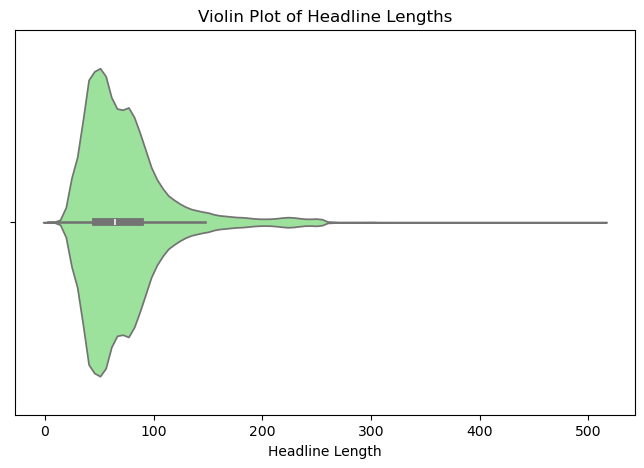

In [8]:
# Convert the date column to datetime format
# Using format='%Y-%m-%d %H:%M:%S' to match the data format
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S', errors='coerce', utc=True)

## Descriptive Statistics for textual lengths (like headline length)
df['headline_length'] = df['headline'].apply(len)
headline_stats = df['headline_length'].describe()
print("Descriptive Statistics for Headline Lengths:")
print(headline_stats)

# Visualize the distribution of headline lengths
plt.figure(figsize=(8, 5))  # Sets the figure size
sns.violinplot(x=df['headline_length'], color='lightgreen') 
plt.title('Violin Plot of Headline Lengths')  
plt.xlabel('Headline Length')  
plt.show()  






Number of Articles per Publisher:
publisher
Paul Quintaro                      228373
Lisa Levin                         186979
Benzinga Newsdesk                  150484
Charles Gross                       96732
Monica Gerson                       82380
                                    ...  
Shazir Mucklai - Imperium Group         1
Laura Jennings                          1
Eric Martin                             1
Jose Rodrigo                            1
Jeremie Capron                          1
Name: count, Length: 1034, dtype: int64


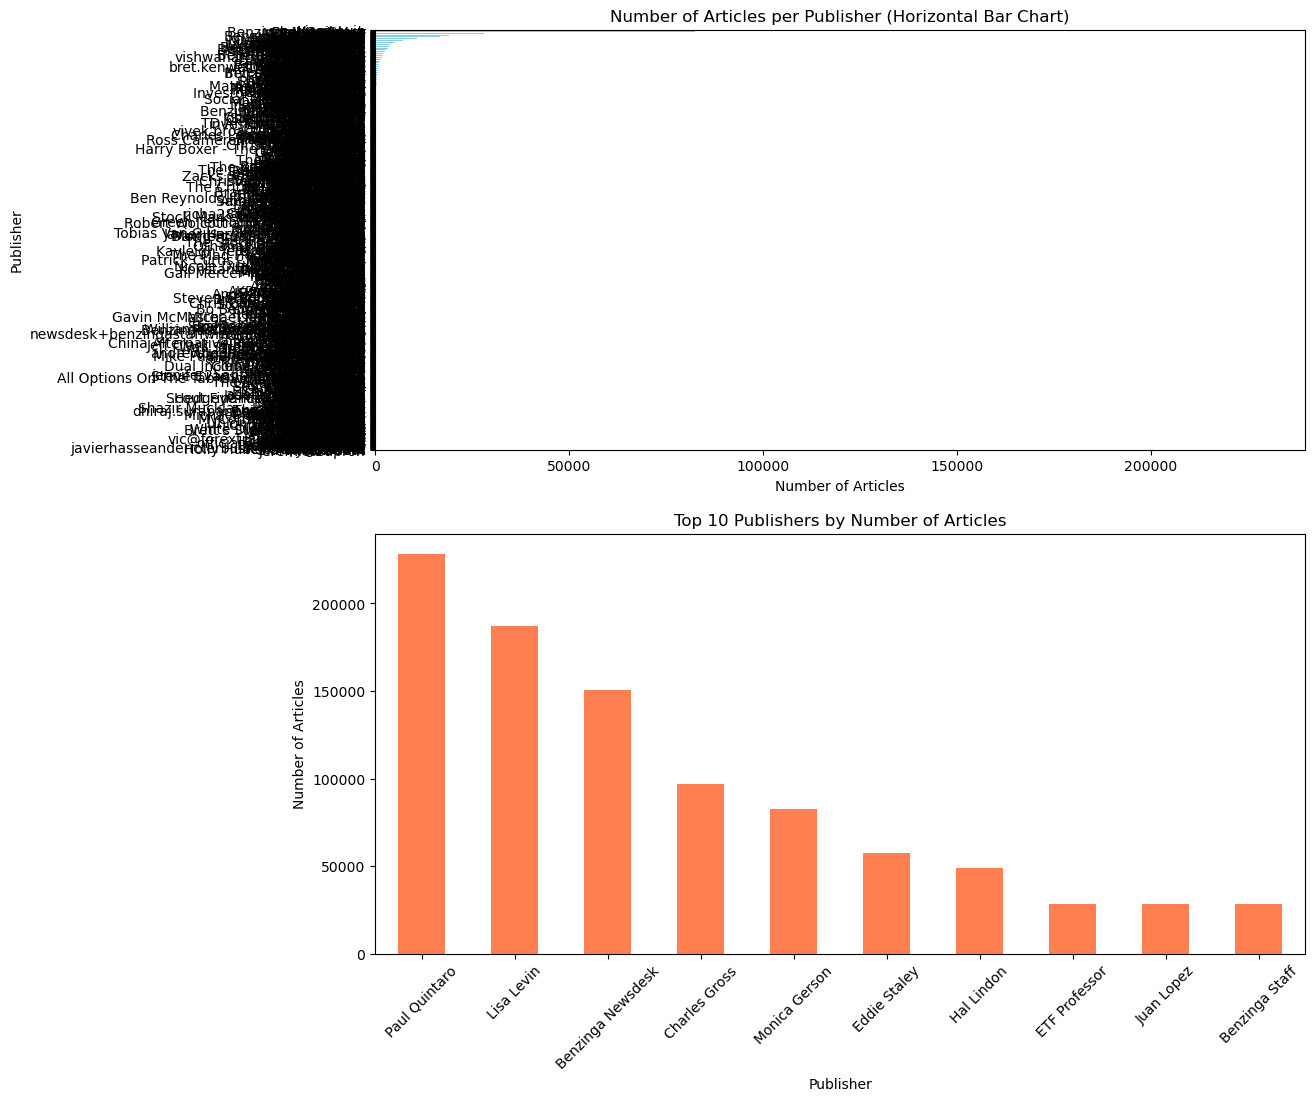

In [20]:

# Data preparation
publisher_counts = df['publisher'].value_counts()
print("\nNumber of Articles per Publisher:")
print(publisher_counts)
top_publishers = publisher_counts.head(10)  # Select top 10 publishers

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 12))  # 2 row, 1 columns

# Plot 1: Horizontal Bar Chart (All Publishers)
publisher_counts.sort_values().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Number of Articles per Publisher (Horizontal Bar Chart)')
axes[0].set_xlabel('Number of Articles')
axes[0].set_ylabel('Publisher')

# Plot 2: Vertical Bar Chart (Top 10 Publishers)
top_publishers.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Publishers by Number of Articles')
axes[1].set_xlabel('Publisher')
axes[1].set_ylabel('Number of Articles')
axes[1].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for clarity

# Adjust layout and display
plt.tight_layout()
plt.show()



Number of Articles Published Over Time:
publication_date
2009-02-14      1
2009-04-27      2
2009-04-29      1
2009-05-22      1
2009-05-27      6
             ... 
2020-05-30     14
2020-05-31     17
2020-06-01    205
2020-06-02    183
2020-06-03     69
Length: 3946, dtype: int64


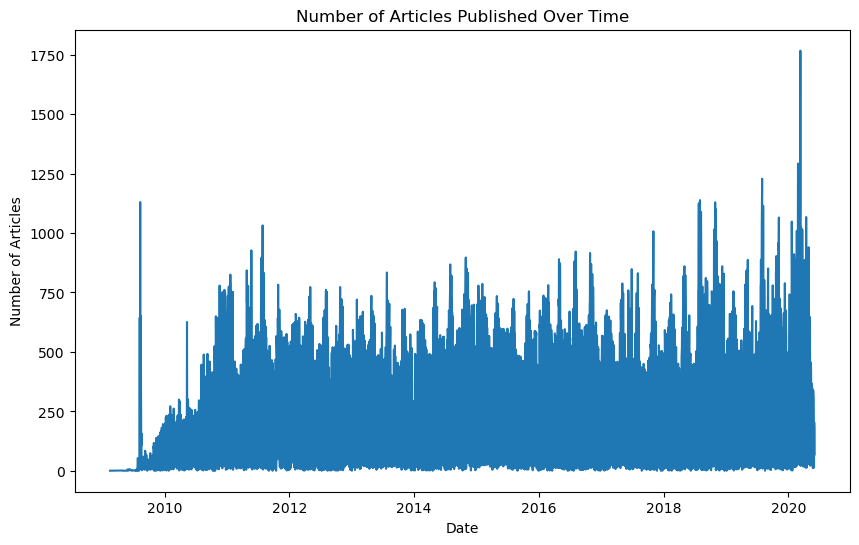


Number of Articles by Day of the Week:
day_of_week
Monday       254842
Tuesday      285468
Wednesday    289049
Thursday     289907
Friday       208511
Saturday       7486
Sunday        16078
Name: count, dtype: int64


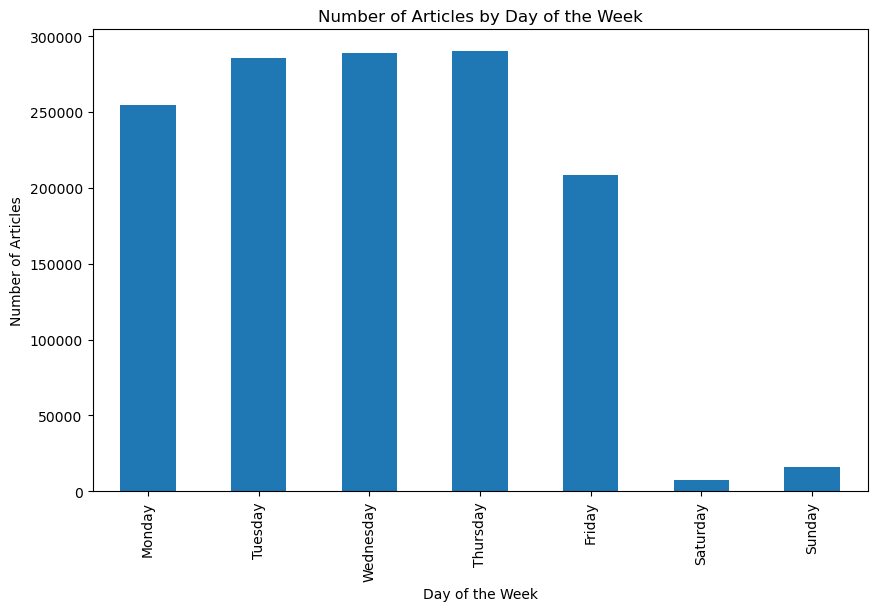

In [22]:
# Analyze publication dates to see trends over time
# Extracting the date part (ignoring the time)
df['publication_date'] = df['date'].dt.date
df['day_of_week'] = df['date'].dt.day_name()

# Group by date to get the number of articles per day
articles_per_day = df.groupby('publication_date').size()

print("\nNumber of Articles Published Over Time:")
print(articles_per_day)

# Visualize the number of articles over time
plt.figure(figsize=(10, 6))
articles_per_day.plot(kind='line')
plt.title('Number of Articles Published Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.show()

# Analyze the number of articles by day of the week
articles_by_day = df['day_of_week'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print("\nNumber of Articles by Day of the Week:")
print(articles_by_day)

# Visualize the number of articles by day of the week
plt.figure(figsize=(10, 6))
articles_by_day.plot(kind='bar')
plt.title('Number of Articles by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Articles')
plt.show()

### Text Analysis(Sentiment analysis & Topic Modeling):

In [24]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [26]:
print(df.isnull().sum())

Unnamed: 0              0
headline                0
url                     0
publisher               0
date                55987
stock                   0
headline_length         0
publication_date    55987
day_of_week         55987
dtype: int64


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype              
---  ------            --------------    -----              
 0   Unnamed: 0        1407328 non-null  int64              
 1   headline          1407328 non-null  object             
 2   url               1407328 non-null  object             
 3   publisher         1407328 non-null  object             
 4   date              1351341 non-null  datetime64[ns, UTC]
 5   stock             1407328 non-null  object             
 6   headline_length   1407328 non-null  int64              
 7   publication_date  1351341 non-null  object             
 8   day_of_week       1351341 non-null  object             
dtypes: datetime64[ns, UTC](1), int64(2), object(6)
memory usage: 96.6+ MB


In [30]:
df.shape

(1407328, 9)

In [34]:
time_data = df['date'].apply(lambda x: pd.notna(x) and isinstance(x, pd.Timestamp) and x.time() != pd.Timestamp.min.time())
print(time_data.sum())


1351341


In [64]:
sentiment_data=df.copy()

from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Calculate the sentiment of the headlines
sentiment_data['sentiment'] = sentiment_data['headline'].apply(lambda x: sia.polarity_scores(text=x)['compound'])
# Categorize the sentiment scores
sentiment_data['sentiment_category'] = pd.cut(sentiment_data['sentiment'], bins=[-1, -0.5, -0.0001, 0.5, 1], labels=['Very Negative', 'Negative', 'Neutral', 'Positive'])
sentiment_data
print(sentiment_data)

         Unnamed: 0                                           headline  \
0                 0            Stocks That Hit 52-Week Highs On Friday   
1                 1         Stocks That Hit 52-Week Highs On Wednesday   
2                 2                      71 Biggest Movers From Friday   
3                 3       46 Stocks Moving In Friday's Mid-Day Session   
4                 4  B of A Securities Maintains Neutral on Agilent...   
...             ...                                                ...   
1407323     1413844             Top Narrow Based Indexes For August 29   
1407324     1413845  Recap: Wednesday's Top Percentage Gainers and ...   
1407325     1413846  UPDATE: Oppenheimer Color on China Zenix Auto ...   
1407326     1413847  Oppenheimer Initiates China Zenix At Outperfor...   
1407327     1413848  China Zenix Auto International Opens For Tradi...   

                                                       url          publisher  \
0        https://www.benzinga.

## Filter sentiment data for each stock

In [71]:
apple_data = sentiment_data[sentiment_data['stock'] == 'AAPL']
AMZN_data = sentiment_data[sentiment_data['stock'] == 'AMZN']
GOOG_data = sentiment_data[sentiment_data['stock'] == 'GOOG']
META_data = sentiment_data[sentiment_data['stock'] == 'META']
NVDA_data = sentiment_data[sentiment_data['stock'] == 'NVDA']
MSFT_data = sentiment_data[sentiment_data['stock'] == 'MSFT']
TSLA_data = sentiment_data[sentiment_data['stock'] == 'TSLA']




### Sentiment of AAPL

      Unnamed: 0                                           headline  \
6680        7120  Tech Stocks And FAANGS Strong Again To Start D...   
6681        7121      10 Biggest Price Target Changes For Wednesday   
6682        7122  Benzinga Pro's Top 5 Stocks To Watch For Wed.,...   
6683        7123  Deutsche Bank Maintains Buy on Apple, Raises P...   
6684        7124  Apple To Let Users Trade In Their Mac Computer...   

                                                    url          publisher  \
6680  https://www.benzinga.com/government/20/06/1622...         JJ Kinahan   
6681  https://www.benzinga.com/analyst-ratings/price...         Lisa Levin   
6682  https://www.benzinga.com/short-sellers/20/06/1...  Benzinga Newsdesk   
6683  https://www.benzinga.com/news/20/06/16219873/d...  Benzinga Newsdesk   
6684  https://www.benzinga.com/news/20/06/16218697/a...      Neer Varshney   

     date stock  headline_length publication_date day_of_week  sentiment  \
6680  NaT  AAPL             

C:\Users\hp\AppData\Local\Temp\ipykernel_13412\3253215879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


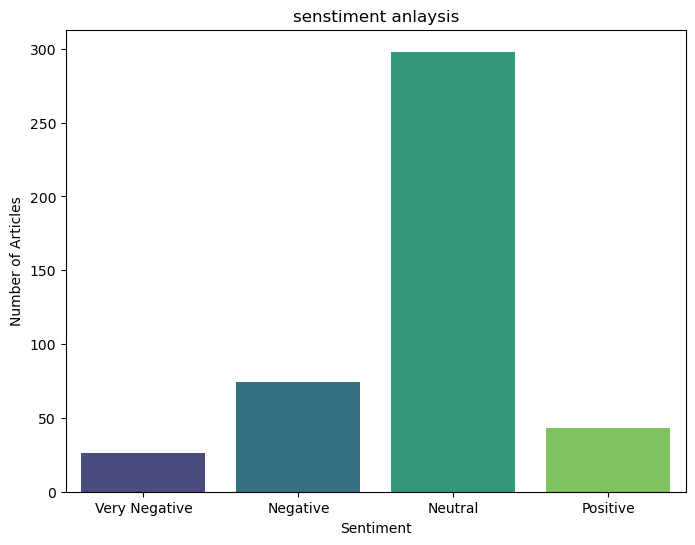

In [73]:

def plot_sentiment_distribution(data, sentiment_column= 'sentiment_category', date_column='date'):
    # Count the sentiment categories
    sentiment_counts = data[sentiment_column].value_counts()
    
    # Print date range
    date_min = data[date_column].min()
    date_max = data[date_column].max()
    print(f"Date range in data: {date_min} to {date_max}")
    
    # Plot the sentiment distribution
    plt.figure(figsize=(8, 6))
    sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
    plt.title("senstiment anlaysis")
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Articles')
    plt.show()

print(apple_data.head())
plot_sentiment_distribution(apple_data)


### Sentiment of AMZN

       Unnamed: 0                                           headline  \
76177       76869  How Cannabis Company Cannaphyll Is Marketing O...   
76178       76870  Tech Stocks And FAANGS Strong Again To Start D...   
76179       76871  Benzinga Pro's Top 5 Stocks To Watch For Wed.,...   
76180       76872  Hearing Vertical Group Out Positive On Amazon,...   
76181       76873  Big Tech Reaches New Record Heights At The Sto...   

                                                     url          publisher  \
76177  https://www.benzinga.com/markets/cannabis/20/0...        Jaycee Tenn   
76178  https://www.benzinga.com/government/20/06/1622...         JJ Kinahan   
76179  https://www.benzinga.com/short-sellers/20/06/1...  Benzinga Newsdesk   
76180  https://www.benzinga.com/analyst-ratings/analy...  Benzinga Newsdesk   
76181  https://www.benzinga.com/news/20/06/16218615/b...      Neer Varshney   

      date stock  headline_length publication_date day_of_week  sentiment  \
76177  NaT  AMZ

C:\Users\hp\AppData\Local\Temp\ipykernel_13412\3253215879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


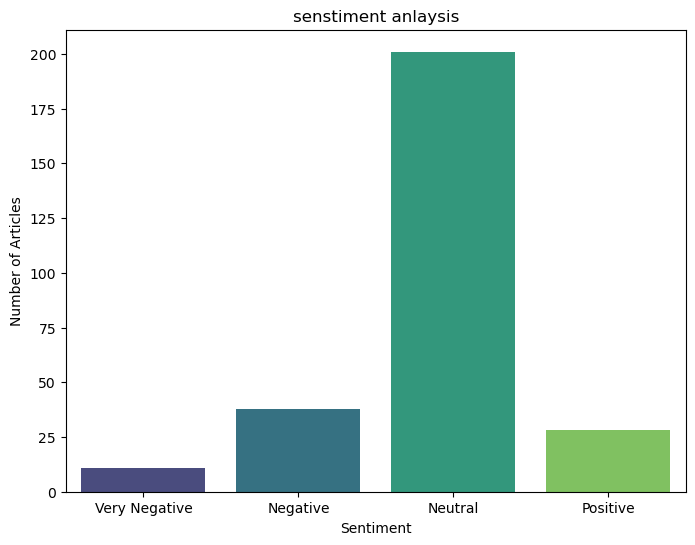

In [75]:
print(AMZN_data.head())
plot_sentiment_distribution(AMZN_data)

### Sentiment of Google

        Unnamed: 0                                           headline  \
565380      568379  Facebook, Snap Analyst Projects Q2 Revenue Ups...   
565381      568380  How Cannabis Company Cannaphyll Is Marketing O...   
565382      568381  Twitter, Square Will Mark Juneteenth As Holida...   
565383      568382             Price Over Earnings Overview: Alphabet   
565384      568383  Google Maps To Offer Relevant Local COVID-19 I...   

                                                      url          publisher  \
565380  https://www.benzinga.com/analyst-ratings/analy...   Shanthi Rexaline   
565381  https://www.benzinga.com/markets/cannabis/20/0...        Jaycee Tenn   
565382  https://www.benzinga.com/news/20/06/16218441/t...  Shivdeep Dhaliwal   
565383  https://www.benzinga.com/intraday-update/20/06...  Benzinga Insights   
565384  https://www.benzinga.com/news/20/06/16208274/g...  Shivdeep Dhaliwal   

       date stock  headline_length publication_date day_of_week  sentiment  \
56

C:\Users\hp\AppData\Local\Temp\ipykernel_13412\3253215879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


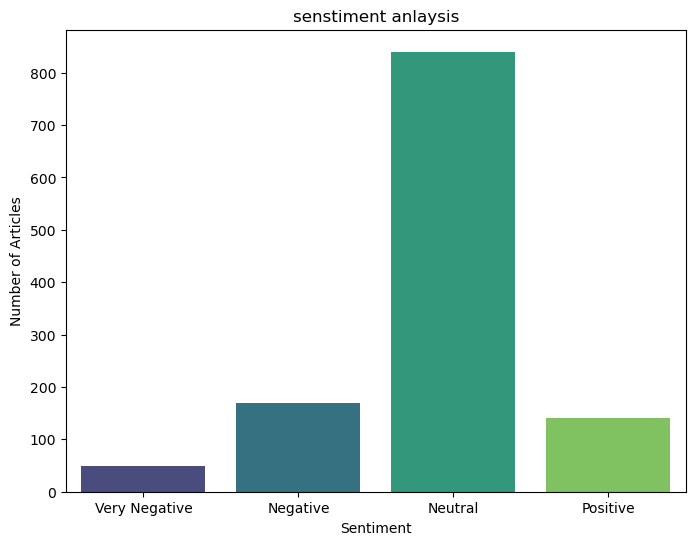

In [81]:

print(GOOG_data.head())
plot_sentiment_distribution(GOOG_data)

### Sentiment of META

Empty DataFrame
Columns: [Unnamed: 0, headline, url, publisher, date, stock, headline_length, publication_date, day_of_week, sentiment, sentiment_category]
Index: []
Date range in data: NaT to NaT


C:\Users\hp\AppData\Local\Temp\ipykernel_13412\3253215879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


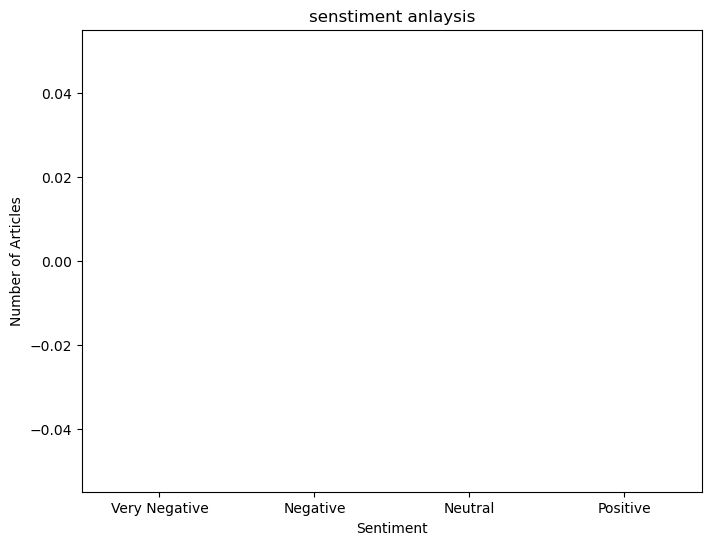

In [85]:
print(META_data.head())

plot_sentiment_distribution(META_data)

### Sentiment of MSFT

Empty DataFrame
Columns: [Unnamed: 0, headline, url, publisher, date, stock, headline_length, publication_date, day_of_week, sentiment, sentiment_category]
Index: []
Date range in data: NaT to NaT


C:\Users\hp\AppData\Local\Temp\ipykernel_13412\3253215879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


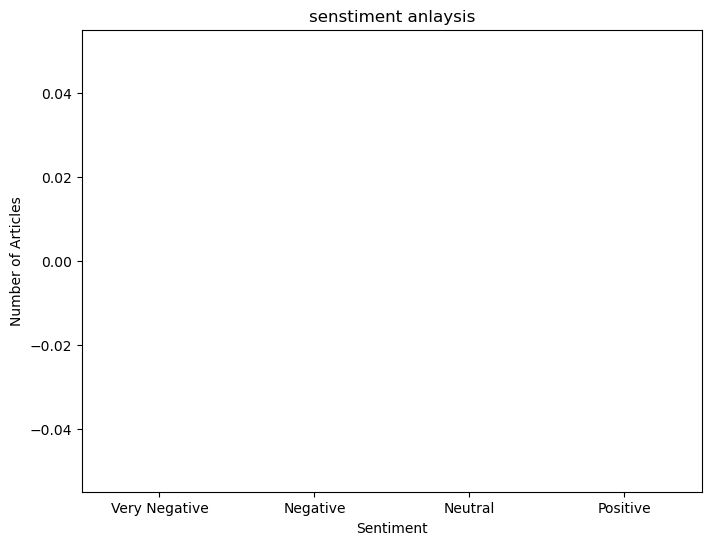

In [91]:
print(MSFT_data.head())
plot_sentiment_distribution(MSFT_data)

### Sentiment of NVDA

        Unnamed: 0                                           headline  \
924271      929039  Shares of several technology companies are tra...   
924272      929040                Afternoon Market Stats in 5 Minutes   
924273      929041                  Morning Market Stats in 5 Minutes   
924274      929042  Shares of several technology companies are tra...   
924275      929043                Afternoon Market Stats in 5 Minutes   

                                                      url          publisher  \
924271  https://www.benzinga.com/wiim/20/06/16224173/s...  Benzinga Newsdesk   
924272  https://www.benzinga.com/markets/20/06/1622357...  Benzinga Insights   
924273  https://www.benzinga.com/markets/20/06/1622174...  Benzinga Insights   
924274  https://www.benzinga.com/wiim/20/06/16214789/s...  Benzinga Newsdesk   
924275  https://www.benzinga.com/markets/20/06/1620319...  Benzinga Insights   

       date stock  headline_length publication_date day_of_week  sentiment  \
92

C:\Users\hp\AppData\Local\Temp\ipykernel_13412\3253215879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


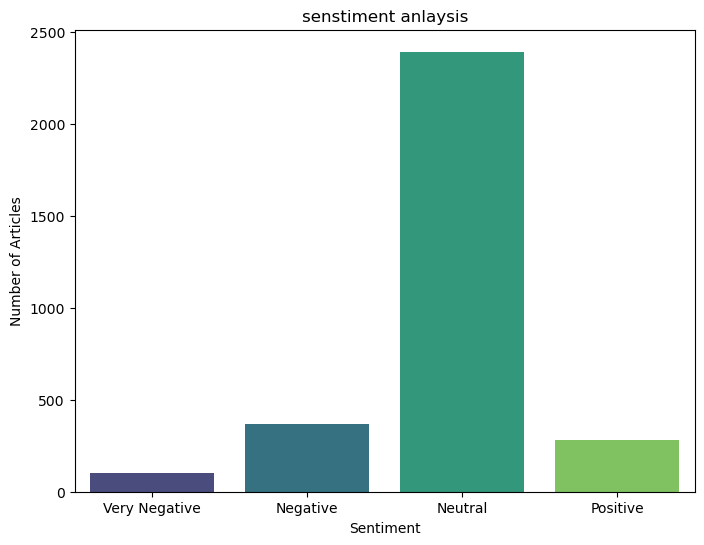

In [87]:
print(NVDA_data.head())
plot_sentiment_distribution(NVDA_data)

### Sentiment of TSLA

         Unnamed: 0                                           headline  \
1255221     1261140  Tesla's Stock Closes At All-Time High As Musk ...   
1255222     1261141  'Tesla factory workplace safety is 5% better t...   
1255223     1261142  'Tesla hacker unlocks Performance upgrade and ...   
1255224     1261143  GM On Track To Spend $20B On EV And AV Develop...   
1255225     1261144                  Tesla's Journey To $1,000 In 2020   

                                                       url          publisher  \
1255221  https://www.benzinga.com/news/20/06/16225150/t...        Drew Levine   
1255222  https://www.benzinga.com/news/20/06/16225621/t...  Benzinga Newsdesk   
1255223  https://www.benzinga.com/news/20/06/16224205/t...  Benzinga Newsdesk   
1255224  https://www.benzinga.com/news/20/06/16223414/g...  Benzinga Newsdesk   
1255225  https://www.benzinga.com/news/20/06/16222035/t...       Wayne Duggan   

        date stock  headline_length publication_date day_of_week  se

C:\Users\hp\AppData\Local\Temp\ipykernel_13412\3253215879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


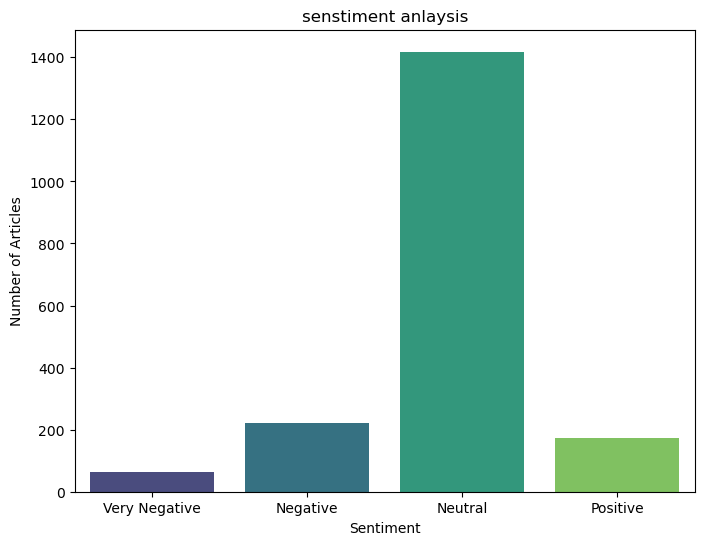

In [89]:
print(TSLA_data.head())

plot_sentiment_distribution(TSLA_data)

### TOPIC Modeling

In [ ]:
# Download stopwords from NLTK
nltk.download('stopwords')

# Preprocessing for topic modeling
def preprocess_text(text):
    text = text.lower()
    text = nltk.RegexpTokenizer(r"\w+").tokenize(text)
    stopwords = nltk.corpus.stopwords.words('english')
    text = [word for word in text if word not in stopwords]
    return ' '.join(text)

# Apply preprocessing
df['processed_headline'] = df['headline'].apply(preprocess_text)

# Vectorize text data
vectorizer = CountVectorizer(max_features=1000)  # Limit to top 1000 words
X = vectorizer.fit_transform(df['processed_headline'])

# Fit LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=0)  # Adjust number of topics as needed
lda.fit(X)

# Get topic terms
feature_names = vectorizer.get_feature_names_out()
topics = lda.components_

# Display top words per topic
num_words = 10
for topic_idx, topic in enumerate(topics):
    print(f"Topic #{topic_idx + 1}:")
    print(" ".join([feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]))
    print()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


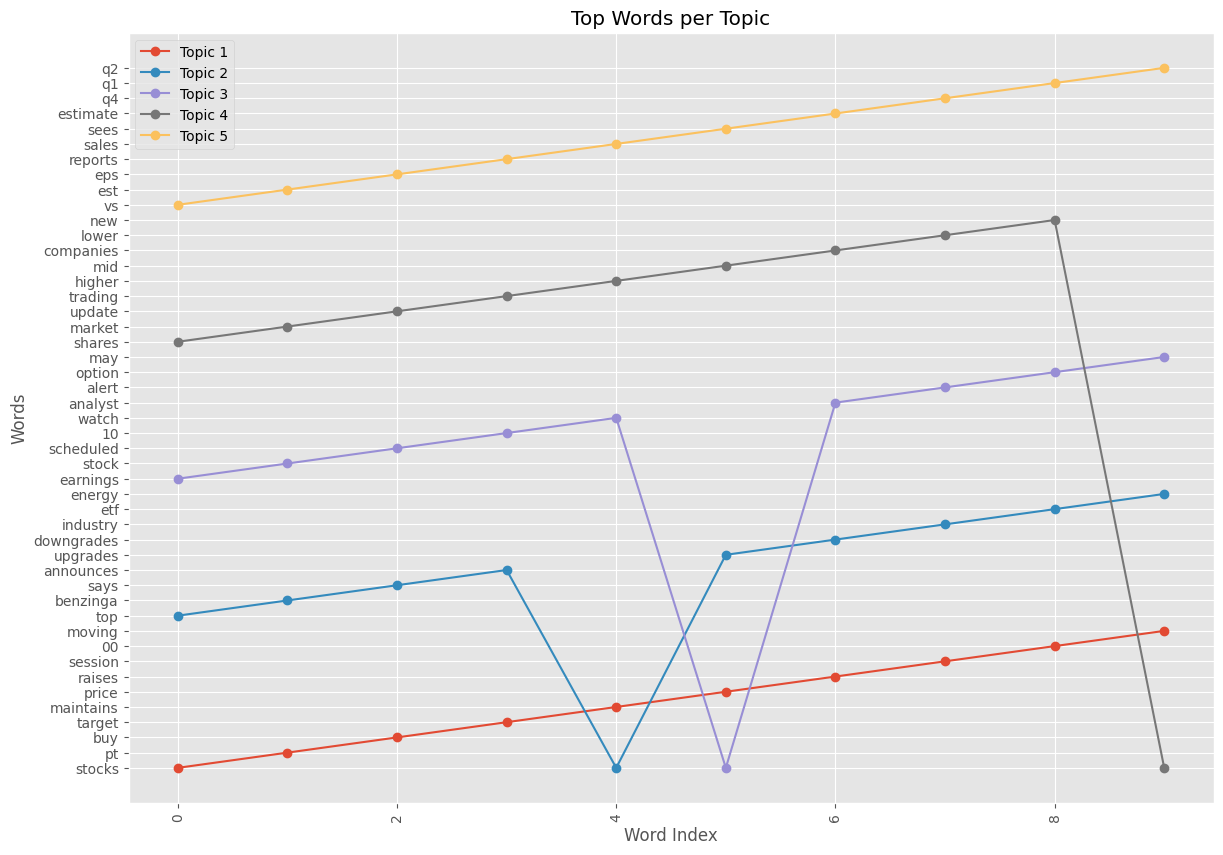

In [62]:
topic_words = []
for topic_idx, topic in enumerate(topics):
    words = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
    topic_words.append(words)

topic_df = pd.DataFrame(topic_words, columns=[f"Word {i+1}" for i in range(num_words)])
topic_df.index.name = 'Topic'

# Plot the top words for each topic
fig, ax = plt.subplots(figsize=(14, 10))
for i, words in enumerate(topic_words):
    ax.plot(words, label=f"Topic {i+1}", marker='o')

ax.set_title('Top Words per Topic')
ax.set_xlabel('Word Index')
ax.set_ylabel('Words')
ax.legend(loc='best')
plt.xticks(rotation=90)
plt.show()

### Time Series Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(r'C:\Users\Hp\Desktop\10_Academy\week-1\Data\raw_analyst_ratings.csv\raw_analyst_ratings.csv')

# Convert the date column to datetime format with timezone information
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S%z', errors='coerce')

# Task 1: Analyze publication frequency over time
# Group by date to get the number of articles per day
df['publication_date'] = df['date'].dt.date
articles_per_day = df.groupby('publication_date').size()

# Visualize the number of articles published over time
plt.figure(figsize=(12, 6))
plt.plot(articles_per_day, label='Number of Articles per Day', color='blue')
plt.title('Number of Articles Published Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.legend()
plt.show()

# Task 2: Identify spikes in publication frequency
# Rolling mean to smooth the series and detect spikes
rolling_mean = articles_per_day.rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.plot(articles_per_day, label='Number of Articles per Day', color='blue', alpha=0.5)
plt.plot(rolling_mean, label='7-Day Rolling Mean', color='red')
plt.title('Publication Frequency with Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.legend()
plt.show()

# Task 3: Analyze the time of day when most news is released
df['time_of_day'] = df['date'].dt.hour

# Count the number of articles published at each hour of the day
articles_by_hour = df['time_of_day'].value_counts().sort_index()

# Visualize the number of articles by hour of the day
plt.figure(figsize=(12, 6))
sns.barplot(x=articles_by_hour.index, y=articles_by_hour.values, color='green')
plt.title('Number of Articles by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Articles')
plt.show()

### Publisher Analysis

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r'C:\Users\Hp\Desktop\10_Academy\week-1\Data\raw_analyst_ratings.csv\raw_analyst_ratings.csv')

# Step 1: Extract Domains from Email Addresses using Regex
def extract_domain(email):

    match = re.search(r'@([\w.-]+)', email)
    return match.group(1) if match else email

df['domain'] = df['publisher'].apply(extract_domain)

# Count the frequency of each domain
domain_counts = df['domain'].value_counts()
print("\nTop Domains:")
print(domain_counts.head(10))  # Adjust the number to your need

# Visualize the top domains

plt.figure(figsize=(10, 6))
domain_counts.head(10).plot(kind='bar')
plt.title('Top Contributing Domains')
plt.xlabel('Domain')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

# Step 2: Use Regex to Identify Patterns in Headlines
# Example: Find headlines mentioning "earnings" or "profit"
df['mention_earnings'] = df['headline'].apply(lambda x: bool(re.search(r'\b(earnings|profit)\b', x, re.IGNORECASE)))

# Count the number of articles mentioning earnings or profit
earnings_count = df['mention_earnings'].sum()
print(f"\nNumber of articles mentioning 'earnings' or 'profit': {earnings_count}")

# Step 3: Analyze the difference in news types by publishers based on regex
# Example: Compare the number of articles mentioning earnings by each publisher
publisher_earnings = df[df['mention_earnings']].groupby('publisher').size()
print("\nNumber of Articles Mentioning 'Earnings' or 'Profit' by Publisher:")
print(publisher_earnings)

# Visualize the comparison
plt.figure(figsize=(10, 6))
publisher_earnings.head(10).plot(kind='bar')
plt.title('Number of Articles Mentioning "Earnings" or "Profit" by Publisher')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()